# Portfolio Risk Analyzer

This notebook demonstrates a long-only portfolio optimization and risk analysis workflow using historical market data.

The analysis compares two portfolio construction approaches:

- **Minimum Variance Portfolio** - minimizes portfolio variance.
- **Maximum Sharpe Portfolio** - maximizes historical risk-adjusted return.

The objective is to compare a **Minimum Variance Portfolio** with a **Maximum Sharpe Portfolio** and examine how two optimization approaches affect portfolio allocation and risk-return characteristics.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.ticker import PercentFormatter

from portfolio_risk_analyzer.data import (
    download_prices, 
    calculate_returns, 
    annualize_mean_returns, 
    annualize_covariance
)

from portfolio_risk_analyzer.metrics import (
    portfolio_returns
)

from portfolio_risk_analyzer.optimization import (
    minimum_variance_weights,
    maximum_sharpe_weights, 
    efficient_frontier
)

from portfolio_risk_analyzer.reporting import (
    portfolio_summary
)

from portfolio_risk_analyzer.risk import (
    drawdown_series
)

## Analysis Setup

The investment universe consists of five ETFs providing exposure to different asset classes and market segments:

- **SPY** - U.S. large-cap equities (S&P 500)
- **TLT** - long-term U.S. government bonds
- **GLD** - gold exposure
- **EEM** - emerging-market equities
- **VNQ** - U.S. real estate

Historical adjusted prices are downloaded from Yahoo Finance starting from January 2020.

Key assumptions:

- long-only portfolios,
- fully invested portfolio: weights sum to 100%,
- no transaction costs or taxes,
- daily returns are used to risk calculations,
- expected returns and covariance are annualized using 252 trading days,
- risk-free rate: **4%**,
- portfolio weights are estimated using the full historical sample.

In [2]:
tickers = ['SPY', 'TLT', 'GLD', 'EEM', 'VNQ']

prices = download_prices(
    tickers,
    start='2020-01-01'
)

daily_returns = calculate_returns(prices)

annual_mean_returns = annualize_mean_returns(
    daily_returns
)

annual_cov_matrix = annualize_covariance(
    daily_returns
)

risk_free_rate = 0.04

[*********************100%***********************]  5 of 5 completed


## Portfolio Optimization

Two long-only portfolios are constructed:

- **Minimum Variance Portfolio** - minimizes portfolio variance.
- **Maximum Sharpe Portfolio** - maximizes expected excess return per unit of volatility.

The efficient frontier is generated by minimizing portfolio variance for a range of target expected returns.

In [3]:
max_sharpe_weights = maximum_sharpe_weights(
    annual_mean_returns,
    annual_cov_matrix,
    risk_free_rate
)

min_var_weights = minimum_variance_weights(
    annual_cov_matrix
)

summary = portfolio_summary(
    daily_returns,
    max_sharpe_weights,
    annual_mean_returns,
    annual_cov_matrix,
    risk_free_rate
)

min_var_summary = portfolio_summary(
    daily_returns,
    min_var_weights,
    annual_mean_returns,
    annual_cov_matrix,
    risk_free_rate
)

frontier = efficient_frontier(
    annual_mean_returns,
    annual_cov_matrix
)

portfolio_comparison = pd.DataFrame({
    'Minimum Variance': min_var_summary,
    'Maximum Sharpe': summary
})

### Efficient Frontier

The efficient frontier represents portfolios with the lowest achievable volatility for a given expected return under the long-only constraint.

The **Minimum Variance Portfolio** marks the lowest-risk point on the frontier, while the **Maximum Sharpe Portfolio** identifies the portfolio with the highest historical risk-adjusted resturn.

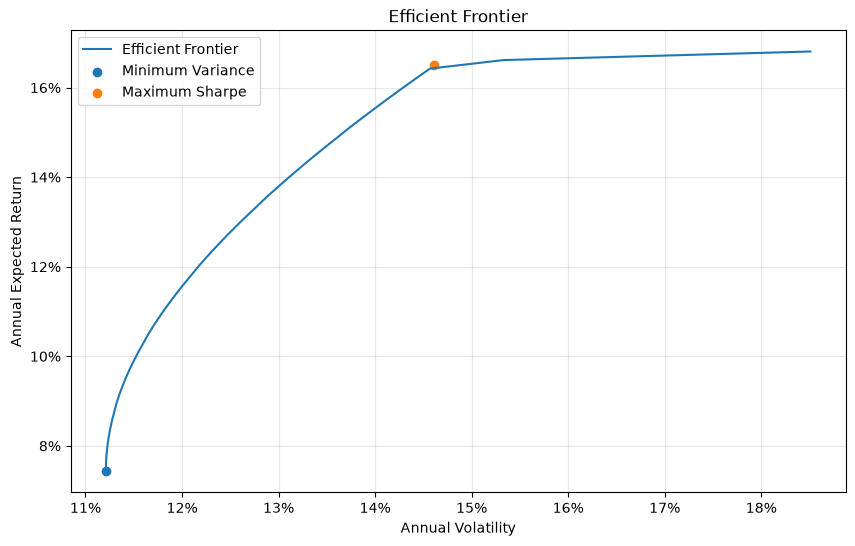

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    frontier['annual_volatility'], 
    frontier['annual_return'],
    label='Efficient Frontier'
)

ax.scatter(
    x=min_var_summary['annual_volatility'],
    y=min_var_summary['annual_return'],
    label='Minimum Variance'
)

ax.scatter(
    x=summary['annual_volatility'],
    y=summary['annual_return'],
    label='Maximum Sharpe'
)

ax.set_xlabel('Annual Volatility')
ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.set_ylabel('Annual Expected Return')
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))

ax.set_title('Efficient Frontier')
ax.legend()
ax.grid(alpha=0.3)

plt.show()

The **Maximum Sharpe Portfolio** lies above the **Minimum Variance Portfolio** on the efficient frontier, offering a higher expected return at the cost of higher volatility.

The **Minimum Variance Portfolio** prioritizes risk reduction, while the **Maximum Sharpe Portfolio** accepts additional volatility in exchange for a higher expected excess return.

### Portfolio Weights

The optimized portfolio weights highlight how the two objectives lead to different asset allocations.

The **Minimum Variance Portfolio** emphasizes diversification and volatility reduction, while the **Maximum Sharpe Portfolio** concentrates capital in assets that historically offered the strongest risk-adjusted contribution.

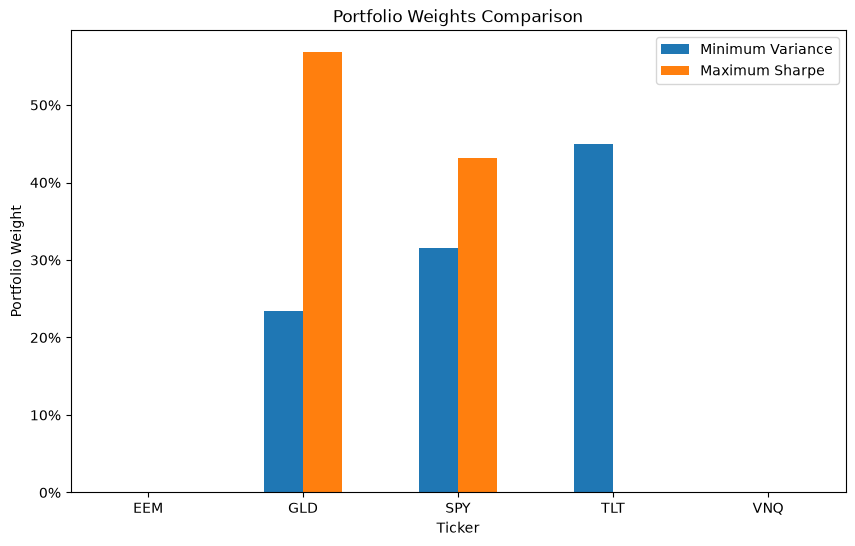

In [5]:
weights_comparison = pd.DataFrame({
    'Minimum Variance': min_var_weights,
    'Maximum Sharpe': max_sharpe_weights
}, index=annual_mean_returns.index)

ax = weights_comparison.plot(
    kind='bar',
    figsize=(10, 6)
)

ax.yaxis.set_major_formatter(
    PercentFormatter(1.0, decimals=0)
)

ax.set_xlabel('Ticker')
ax.set_ylabel('Portfolio Weight')
ax.set_title('Portfolio Weights Comparison')
ax.tick_params(axis='x', rotation=0)

plt.show()

The **Minimum Variance Portfolio** allocates most of its capital to TLT, SPY and GLD, while the **Maximum Sharpe Portfolio** is concentrated almost entirely in GLD and SPY.

EEM and VNQ receive approximately zero weight in both optimized portfolios under the historical sample and imposed long-only constraints.

## Portfolio Comparison

The two optimized portfolios are compared using return, volatility and downside risk measures.

Annual return and volatility are annualized, while historical VaR and CVaR are calculated from daily portfolio returns at a 95% confidence level.

In [6]:
portfolio_comparison_display = portfolio_comparison.copy()

portfolio_comparison_display.rename(index={
    'annual_return': 'Annual Return',
    'annual_volatility': 'Annual Volatility',
    'sharpe_ratio': 'Sharpe Ratio',
    'max_drawdown': 'Max Drawdown',
    'historical_var': 'Historical VaR',
    'historical_cvar': 'Historical CVaR'
}, inplace=True)

percent_rows = [
    'Annual Return',
    'Annual Volatility',
    'Max Drawdown',
    'Historical VaR',
    'Historical CVaR'
]

portfolio_comparison_display.style \
    .format(
        '{:.2%}',
        subset=pd.IndexSlice[percent_rows, :]
    ) \
    .format(
        '{:.2f}',
        subset=pd.IndexSlice[['Sharpe Ratio'], :]
    )

,Minimum Variance,Maximum Sharpe
Annual Return,7.43%,16.50%
Annual Volatility,11.21%,14.61%
Sharpe Ratio,0.31,0.86
Max Drawdown,-25.40%,-18.85%
Historical VaR,1.13%,1.36%
Historical CVaR,1.57%,2.19%


The **Maximum Sharpe Portfolio** achieved a substantially higher historical annualized return and Sharpe ratio, but also exhibited higher volatility and more severe daily tail losses measured by VaR and CVaR.

The **Minimum Variance Portfolio** reduced volatility and daily tail risk, but produced a lower historical return. Interestingly, its maximum drawdown was deeper than that of the **Maximum Sharpe Portfolio**, illustrating that lower volatility does not necessarily imply a lower maximum drawdown.

## Historical Performance

The cumulative performance chart illustrates how an initial $1 investment would have evolved under the two optimized portfolios over the historical sample.

Because portfolio weights are estimated using the same historical period used for the performance calculation, the results should be interpreted as an in-sample reconstruction rather than out-of-sample backtest.

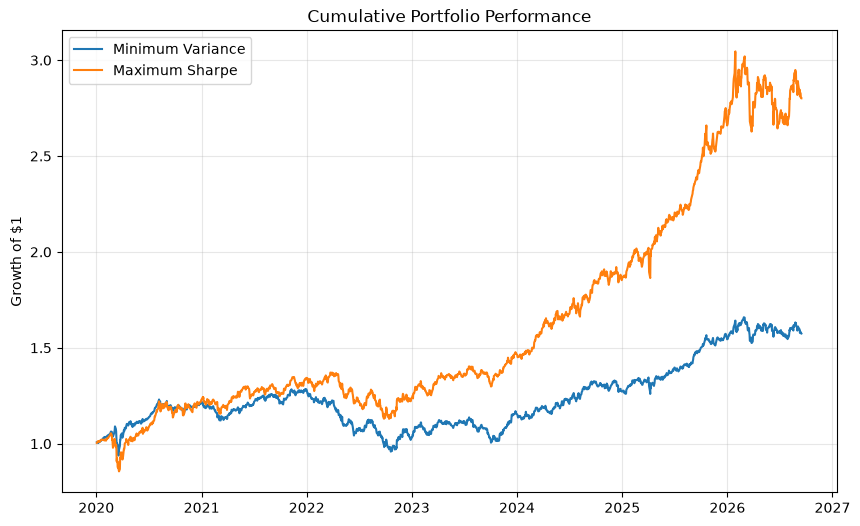

In [7]:
min_var_daily_returns = portfolio_returns(
    daily_returns,
    min_var_weights
)

max_sharpe_daily_returns = portfolio_returns(
    daily_returns,
    max_sharpe_weights
)

cumulative_comparison = pd.DataFrame({
    'Minimum Variance': (1 + min_var_daily_returns).cumprod(),
    'Maximum Sharpe': (1 + max_sharpe_daily_returns).cumprod()
})

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    cumulative_comparison.index,
    cumulative_comparison['Minimum Variance'],
    label='Minimum Variance'
)

ax.plot(
    cumulative_comparison.index,
    cumulative_comparison['Maximum Sharpe'],
    label='Maximum Sharpe'
)

ax.set_ylabel('Growth of $1')
ax.set_title('Cumulative Portfolio Performance')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

The **Maximum Sharpe Portfolio** generated substantially higher cumulative growth over the sample period, while the **Minimum Variance Portfolio** followed a smoother but lower-growth path.

The difference reflects the distinct optimization objectives: the **Maximum Sharpe Portfolio** accepts higher volatility in exchange for stronger historical risk-adjusted return, whereas the **Minimum Variance Portfolio** prioritizes volatility reduction.

### Drawdown Analysis

Drawdown measures the decline of a portfolio from its previous historical peak and provides a different perspective on risk than volatility.

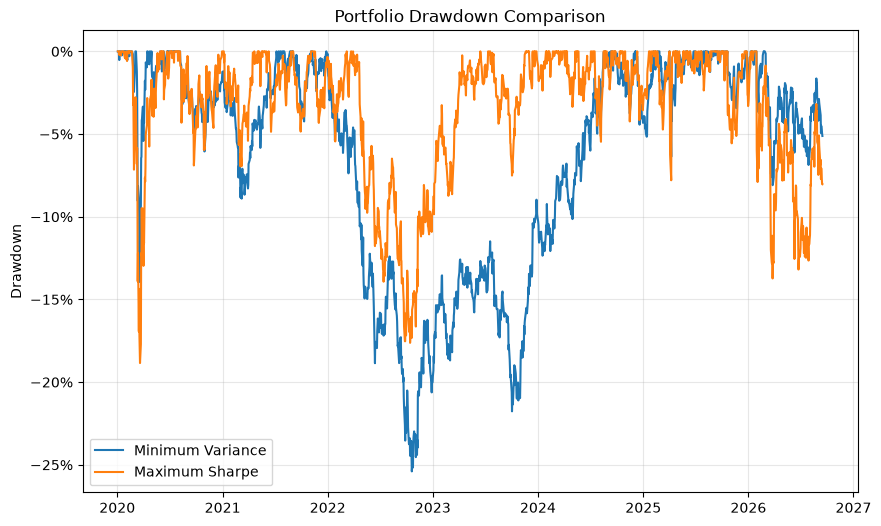

In [8]:
min_var_drawdown = drawdown_series(
    min_var_daily_returns
)

max_sharpe_drawdown = drawdown_series(
    max_sharpe_daily_returns
)

drawdown_comparison = pd.DataFrame({
    'Minimum Variance': min_var_drawdown,
    'Maximum Sharpe': max_sharpe_drawdown
})

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    drawdown_comparison.index,
    drawdown_comparison['Minimum Variance'],
    label='Minimum Variance'
)

ax.plot(
    drawdown_comparison.index,
    drawdown_comparison['Maximum Sharpe'],
    label='Maximum Sharpe'
)

ax.yaxis.set_major_formatter(
    PercentFormatter(1.0, decimals=0)
)

ax.set_ylabel('Drawdown')
ax.set_title('Portfolio Drawdown Comparison')
ax.legend()
ax.grid(alpha=0.3)

plt.show()

Despite having lower annual volatility, the **Minimum Variance Portfolio** experienced a deeper maximum drawdown over the historical sample.

This illustrates that volatility and drawdown capture different dimension of portfolio risk: lower variability of daily returns does not necessarily imply a smaller peak-to-trough loss.

## Key Findings

- The **Minimum Variance Portfolio** achieved lower annual volatility and lower daily tail risk, but also produced a substantially lower historical annualized return.
- The **Maximum Sharpe Portfolio** delivered a higher historical risk-adjusted return and stronger cumulative growth, at the cost of higher volatility and larger daily tail losses.
- The optimized portfolios produced materially different asset allocations, reflecting their different objective functions.
- Lower volatility did not translate into a lower maximum drawdown, highlighting that volatility and drawdown capture different dimensions of portfolio risk.
- All results are based on the same historical sample used for portfolio optimization and should therefore be interpreted as in-sample analysis rather than evidence of future performance.

## Methodology Notes

- Adjusted closing prices are used.
- Daily arithmetic returns are calculated from price changes.
- Expected returns and covariance are annualized using 252 trading days.
- Portfolio optimization is long-only with weights constrained between 0% and 100% and summing to 100%.
- Historical VaR and CVaR are calculated at a 95% confidence level using daily portfolio returns.